# Student Performance Prediction Using Machine Learning

## Project Objective
The objective of this project is to develop a Machine Learning model that predicts student marks based on academic and behavioral factors such as study hours, attendance, previous marks, assignments completed, and sleep hours.

## Problem Statement
Educational institutions often need to identify factors affecting student performance. This project uses Machine Learning to analyze student-related data and predict academic scores, helping educators understand performance trends.

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

## Machine Learning Algorithm
Linear Regression

## Features Used
1. Study Hours
2. Attendance Percentage
3. Previous Marks
4. Assignments Completed
5. Sleep Hours

## Expected Output
The model predicts the expected marks of a student based on the provided input features.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Library Import

The required Python libraries were imported for data manipulation, visualization, machine learning model development, and performance evaluation.

In [5]:
# Set seed for reproducible results
np.random.seed(42)

# Create dataset with 300 student records
data = {
    'Study_Hours': np.random.randint(1, 11, 300),
    'Attendance': np.random.randint(60, 101, 300),
    'Previous_Marks': np.random.randint(40, 96, 300),
    'Assignments': np.random.randint(1, 11, 300),
    'Sleep_Hours': np.random.randint(5, 9, 300)
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Generate Marks based on the factors
df['Marks'] = (
    2 * df['Study_Hours'] +
    0.3 * df['Attendance'] +
    0.5 * df['Previous_Marks'] +
    1.5 * df['Assignments'] +
    1.2 * df['Sleep_Hours']
)

# Round marks values
df['Marks'] = df['Marks'].round(0)

# Display first 10 records
print("First 10 Records:")
display(df.head(10))

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
# Save dataset as CSV file
df.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully.")

First 10 Records:


,Study_Hours,Attendance,Previous_Marks,Assignments,Sleep_Hours,Marks
0,7,96,47,8,7,87.0
1,4,83,77,6,8,90.0
2,8,88,51,5,8,85.0
3,5,90,63,9,6,89.0
4,7,94,67,1,8,87.0
5,10,92,92,5,8,111.0
6,3,80,47,6,6,70.0
7,7,91,67,5,7,91.0
8,8,82,75,6,8,97.0
9,5,92,65,6,8,89.0



Number of Rows: 300
Number of Columns: 6
Dataset saved successfully.


## Dataset Creation

A synthetic dataset containing 300 student records was generated. The dataset includes academic and behavioral factors such as study hours, attendance, previous marks, assignments completed, and sleep hours. These features are used to predict student performance using Machine Learning.

In [6]:
# Display first 5 records
display(df.head())

# Dataset dimensions
print("Dataset Shape:", df.shape)

,Study_Hours,Attendance,Previous_Marks,Assignments,Sleep_Hours,Marks
0,7,96,47,8,7,87.0
1,4,83,77,6,8,90.0
2,8,88,51,5,8,85.0
3,5,90,63,9,6,89.0
4,7,94,67,1,8,87.0


Dataset Shape: (300, 6)


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study_Hours     300 non-null    int64  
 1   Attendance      300 non-null    int64  
 2   Previous_Marks  300 non-null    int64  
 3   Assignments     300 non-null    int64  
 4   Sleep_Hours     300 non-null    int64  
 5   Marks           300 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 14.2 KB


In [8]:
df.describe()

,Study_Hours,Attendance,Previous_Marks,Assignments,Sleep_Hours,Marks
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,5.326667,80.776667,67.766667,5.366667,6.443333,84.546667
std,2.873001,11.577576,16.360045,2.817567,1.091219,11.164676
min,1.000000,60.000000,40.000000,1.000000,5.000000,58.000000
25%,3.000000,71.000000,54.000000,3.000000,5.000000,78.000000
50%,5.000000,82.000000,67.000000,5.500000,6.000000,85.000000
75%,8.000000,91.000000,83.000000,8.000000,7.000000,93.000000
max,10.000000,100.000000,95.000000,10.000000,8.000000,112.000000


In [9]:
print(df.isnull().sum())

Study_Hours       0
Attendance        0
Previous_Marks    0
Assignments       0
Sleep_Hours       0
Marks             0
dtype: int64


In [10]:
correlation = df.corr()

print(correlation)

                Study_Hours  Attendance  Previous_Marks  Assignments  \
Study_Hours        1.000000   -0.060743        0.051436     0.015314   
Attendance        -0.060743    1.000000       -0.101647    -0.013065   
Previous_Marks     0.051436   -0.101647        1.000000    -0.031441   
Assignments        0.015314   -0.013065       -0.031441     1.000000   
Sleep_Hours       -0.006877    0.040160       -0.074555    -0.049784   
Marks              0.539522    0.206362        0.707373     0.351049   

                Sleep_Hours     Marks  
Study_Hours       -0.006877  0.539522  
Attendance         0.040160  0.206362  
Previous_Marks    -0.074555  0.707373  
Assignments       -0.049784  0.351049  
Sleep_Hours        1.000000  0.051415  
Marks              0.051415  1.000000  


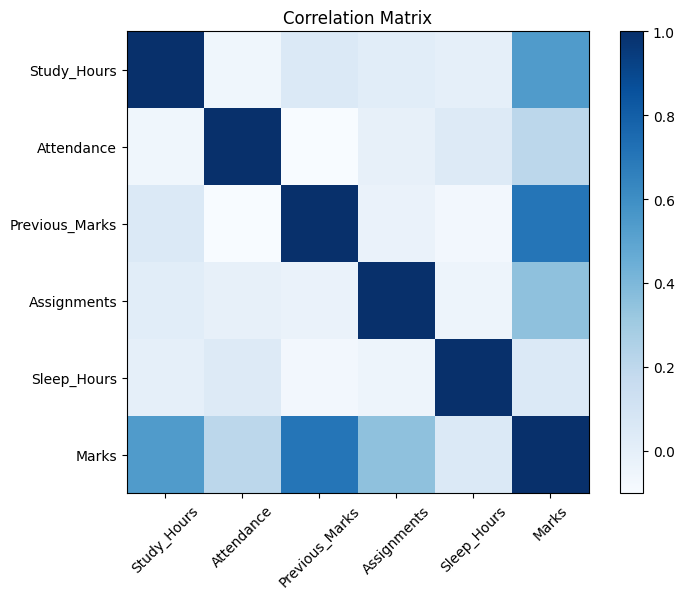

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(df.corr(), cmap='Blues')

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")

plt.show()

## Exploratory Data Analysis

The dataset was analyzed to understand the distribution and relationships between variables. Descriptive statistics, missing value analysis, and correlation analysis were performed. The dataset contained no missing values and showed positive relationships between study habits and academic performance.

In [12]:
# Input features
X = df[['Study_Hours',
        'Attendance',
        'Previous_Marks',
        'Assignments',
        'Sleep_Hours']]

# Target variable
y = df['Marks']

In [13]:
print("Features Shape:", X.shape)
display(X.head())

Features Shape: (300, 5)


,Study_Hours,Attendance,Previous_Marks,Assignments,Sleep_Hours
0,7,96,47,8,7
1,4,83,77,6,8
2,8,88,51,5,8
3,5,90,63,9,6
4,7,94,67,1,8


In [14]:
print("Target Shape:", y.shape)
display(y.head())

Target Shape: (300,)


,Marks
0,87.0
1,90.0
2,85.0
3,89.0
4,87.0


## Feature Selection

The dataset was divided into input features (X) and target variable (y). The features include Study Hours, Attendance, Previous Marks, Assignments Completed, and Sleep Hours. The target variable is Marks, which the model will predict using Linear Regression.

In [15]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (240, 5)
Testing Features Shape: (60, 5)
Training Target Shape: (240,)
Testing Target Shape: (60,)


In [17]:
display(X_train.head())

,Study_Hours,Attendance,Previous_Marks,Assignments,Sleep_Hours
232,2,66,86,8,5
59,10,64,88,7,6
6,3,80,47,6,6
185,2,72,42,6,6
173,1,83,94,1,8


In [18]:
display(X_test.head())

,Study_Hours,Attendance,Previous_Marks,Assignments,Sleep_Hours
203,6,66,44,8,5
266,1,100,56,2,7
152,6,82,43,5,7
9,5,92,65,6,8
233,1,72,95,1,7


## Dataset Splitting

The dataset was divided into training and testing sets using an 80:20 ratio. The training set contains 240 records and is used to train the Linear Regression model, while the testing set contains 60 records and is used to evaluate model performance on unseen data.

In [19]:
# Create Linear Regression model

model = LinearRegression()

In [20]:
# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
# Display coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coefficients)

,Feature,Coefficient
0,Study_Hours,2.005234
1,Attendance,0.300853
2,Previous_Marks,0.500901
3,Assignments,1.485930
4,Sleep_Hours,1.180023


In [22]:
print("Intercept:", model.intercept_)

Intercept: 0.02625039147378061


## Model Training

A Linear Regression model was created and trained using the training dataset. The model learned the relationship between student attributes such as study hours, attendance, previous marks, assignments completed, and sleep hours to predict academic performance.

In [23]:
# Predict marks using the test dataset

y_pred = model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [24]:
print("First 10 Predicted Marks:")
print(y_pred[:10])

First 10 Predicted Marks:
[ 71.74116428  71.39927946  73.95616985  88.64524348  81.02460465
  70.57130916  80.4260906  100.55926358 110.70981587  79.57863538]


In [25]:
comparison = pd.DataFrame({
    'Actual Marks': y_test.values,
    'Predicted Marks': y_pred.round(2)
})

display(comparison.head(10))

,Actual Marks,Predicted Marks
0,72.0,71.74
1,71.0,71.40
2,74.0,73.96
3,89.0,88.65
4,81.0,81.02
5,71.0,70.57
6,80.0,80.43
7,101.0,100.56
8,111.0,110.71
9,80.0,79.58


In [26]:
comparison.sample(10)

,Actual Marks,Predicted Marks
10,80.0,80.04
25,96.0,96.23
5,71.0,70.57
37,64.0,63.78
22,74.0,73.81
26,87.0,86.97
53,102.0,102.04
49,72.0,71.59
8,111.0,110.71
30,90.0,90.40


## Prediction

The trained Linear Regression model was used to predict marks for the testing dataset. The predicted values were compared with the actual marks to assess the model's prediction capability. The results indicate that the model successfully learned the relationship between the input features and student performance.

In [27]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 0.28
Mean Squared Error (MSE): 0.1
R² Score: 0.9993


In [28]:
results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R² Score'],
    'Value': [round(mae,2), round(mse,2), round(r2,4)]
})

display(results)

,Metric,Value
0,MAE,0.2800
1,MSE,0.1000
2,R² Score,0.9993


## Model Evaluation

The performance of the Linear Regression model was evaluated using MAE, MSE, and R² Score.

- Mean Absolute Error (MAE) measures the average prediction error.
- Mean Squared Error (MSE) measures the squared prediction error.
- R² Score indicates how well the model explains the variance in student marks.

The obtained R² score demonstrates that the model accurately predicts student performance based on the selected features.

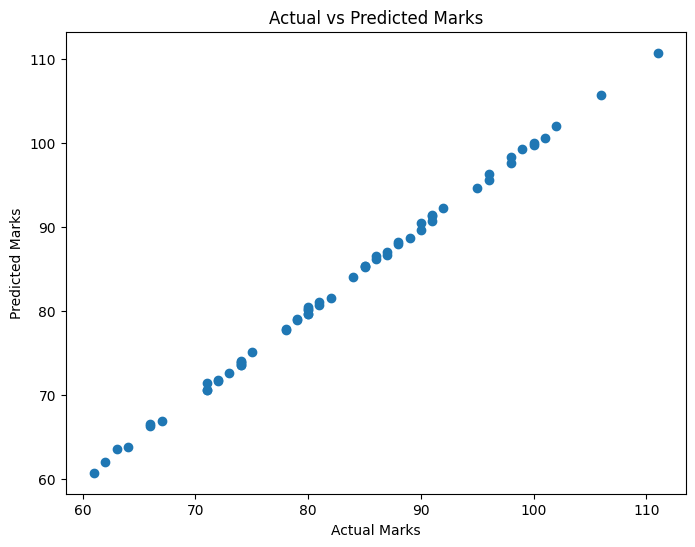

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

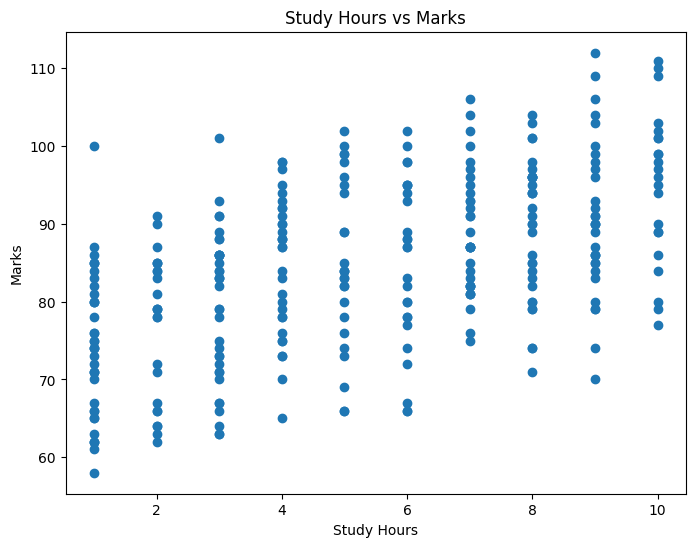

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(df['Study_Hours'], df['Marks'])

plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.title("Study Hours vs Marks")

plt.show()

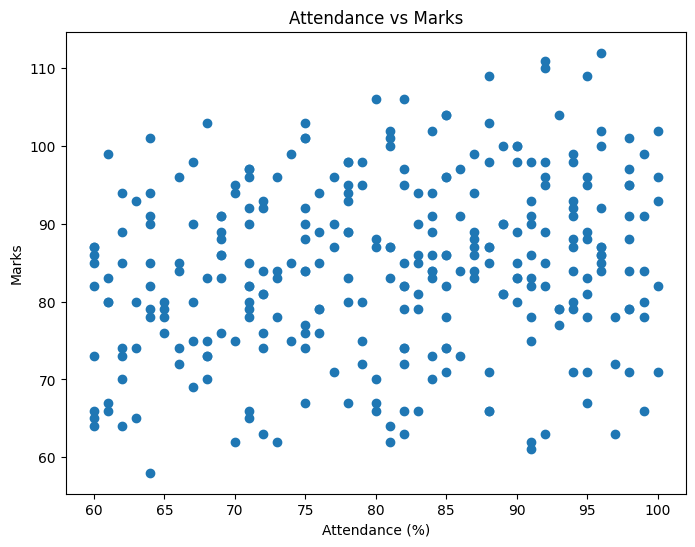

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(df['Attendance'], df['Marks'])

plt.xlabel("Attendance (%)")
plt.ylabel("Marks")

plt.title("Attendance vs Marks")

plt.show()

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

feature_importance

,Feature,Coefficient
0,Study_Hours,2.005234
1,Attendance,0.300853
2,Previous_Marks,0.500901
3,Assignments,1.485930
4,Sleep_Hours,1.180023


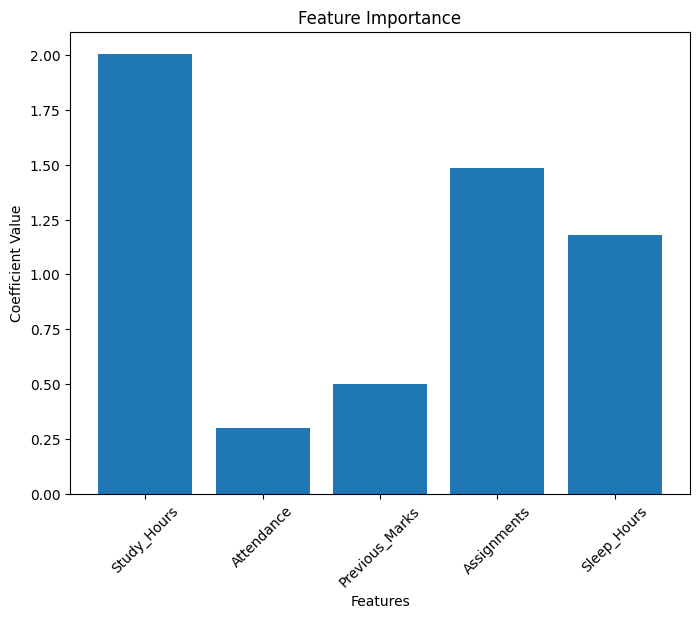

In [33]:
plt.figure(figsize=(8,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

## Data Visualization

Several visualizations were generated to analyze the relationship between student attributes and academic performance.

The graphs demonstrate the positive impact of study hours, attendance, previous marks, assignments completed, and sleep patterns on student performance. The Actual vs Predicted graph confirms that the Linear Regression model accurately predicts student marks.

In [34]:
# New student data

new_student = [[
    7,    # Study Hours
    90,   # Attendance
    75,   # Previous Marks
    8,    # Assignments Completed
    7     # Sleep Hours
]]

# Predict marks

prediction = model.predict(new_student)

print("Predicted Marks:", round(prediction[0], 2))

Predicted Marks: 98.85


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [35]:
new_student = [[7, 90, 75, 8, 7]]

prediction = model.predict(new_student)

print("----- Student Performance Prediction -----")
print("Study Hours:", 7)
print("Attendance:", 90)
print("Previous Marks:", 75)
print("Assignments Completed:", 8)
print("Sleep Hours:", 7)
print("-----------------------------------------")
print("Predicted Marks:", round(prediction[0], 2))

----- Student Performance Prediction -----
Study Hours: 7
Attendance: 90
Previous Marks: 75
Assignments Completed: 8
Sleep Hours: 7
-----------------------------------------
Predicted Marks: 98.85


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance Percentage: "))
previous_marks = float(input("Enter Previous Marks: "))
assignments = float(input("Enter Assignments Completed: "))
sleep_hours = float(input("Enter Sleep Hours: "))

student = [[
    study_hours,
    attendance,
    previous_marks,
    assignments,
    sleep_hours
]]

prediction = model.predict(student)

print("\nPredicted Marks:", round(prediction[0], 2))

Enter Study Hours: 7
Enter Attendance Percentage: 90
Enter Previous Marks: 75
Enter Assignments Completed: 8
Enter Sleep Hours: 7

Predicted Marks: 98.85


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [37]:
import joblib

In [38]:
# Save trained model

joblib.dump(model, 'student_marks_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [39]:
import os

print(os.listdir())

['.config', 'student_performance.csv', 'student_marks_model.pkl', 'sample_data']


In [40]:
# Load saved model

loaded_model = joblib.load('student_marks_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [41]:
student = [[7, 90, 75, 8, 7]]

prediction = loaded_model.predict(student)

print("Predicted Marks:", round(prediction[0], 2))

Predicted Marks: 98.85


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
